### 1 c) Simulación de la ocurrencia de un Shock Séptico
El **shock séptico** es una condición crítica caracterizada por una vasodilatación sistémica profunda como respuesta a una infección grave. Esto genera una caída abrupta de la presión arterial (hipotensión severa) que pone en riesgo la perfusión de los órganos.

Para simular este estado de shock distributivo en nuestro modelo $WK_2$:
* Reduciremos drásticamente la **Resistencia Periférica ($R_P$)** (ej. a un 40% de su valor basal) para reflejar la vasodilatación extrema.
* Aumentaremos moderadamente la **Compliance ($C_A$)** (ej. un 20% por encima del valor basal) debido a la gran relajación del tono vascular.

In [1]:
# -------------------------------------------------------------------------
# MÓDULOS DE USO GENERAL Y FUNCIÓN DE FLUJO (EXCITACIÓN)
# -------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def Q_Sim(Qmax, T, t):
    """
    Generación de una señal de FLUJO (Semiseno) similar al humano [ml/s]
    """
    Escala_ml = 1e5 * (Qmax / 8.8) # Ajuste a (500 ml/s)
    Q = Escala_ml * ((7.9853e-06 + 2.6617e-05*np.sin(2*np.pi*t/T+0.29498) +
                      2.3616e-05*np.sin(4*np.pi*t/T-1.1403) - 1.9016e-05*np.sin(6*np.pi*t/T+0.40435) -
                      8.5899e-06*np.sin(8*np.pi*t/T-1.1892) - 2.436e-06*np.sin(10*np.pi*t/T-1.4918) +
                      1.4905e-06*np.sin(12*np.pi*t/T+1.0536) + 1.3581e-06*np.sin(14*np.pi*t/T-0.47666) -
                      6.3031e-07*np.sin(16*np.pi*t/T+0.93768) - 4.5335e-07*np.sin(18*np.pi*t/T-0.79472) -
                      4.5184e-07*np.sin(20*np.pi*t/T-1.4095) - 5.6583e-07*np.sin(22*np.pi*t/T-1.3629) +
                      4.9522e-07*np.sin(24*np.pi*t/T+0.52495) + 1.3049e-07*np.sin(26*np.pi*t/T-0.97261) -
                      4.1072e-08*np.sin(28*np.pi*t/T-0.15685) - 2.4182e-07*np.sin(30*np.pi*t/T-1.4052) -
                      6.6217e-08*np.sin(32*np.pi*t/T-1.3785) - 1.5511e-07*np.sin(34*np.pi*t/T-1.2927) +
                      2.2149e-07*np.sin(36*np.pi*t/T+0.68178) + 6.7621e-08*np.sin(38*np.pi*t/T-0.98825) +
                      1.0973e-07*np.sin(40*np.pi*t/T+1.4327) - 2.5559e-08*np.sin(42*np.pi*t/T-1.2372) -
                      3.5079e-08*np.sin(44*np.pi*t/T+0.2328)))
    return Q

In [2]:
# -------------------------------------------------------------------------
# RESOLUCIÓN NUMÉRICA DEL MODELO WK2 (MÉTODO DE EULER)
# -------------------------------------------------------------------------

def resolver_wk2_euler(Q, t, Ca, Rp):
    """
    Resuelve la Ecuación Diferencial del Windkessel de 2 elementos
    dP/dt = Q/Ca - P/(Rp*Ca)
    """
    dt = t[1] - t[0]
    P = np.zeros(len(t))

    # Condición inicial (asumimos un arranque bajo por el estado de shock)
    P[0] = 50.0

    for i in range(1, len(t)):
        dP_dt = (Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))
        P[i] = P[i-1] + (dP_dt * dt)

    return P

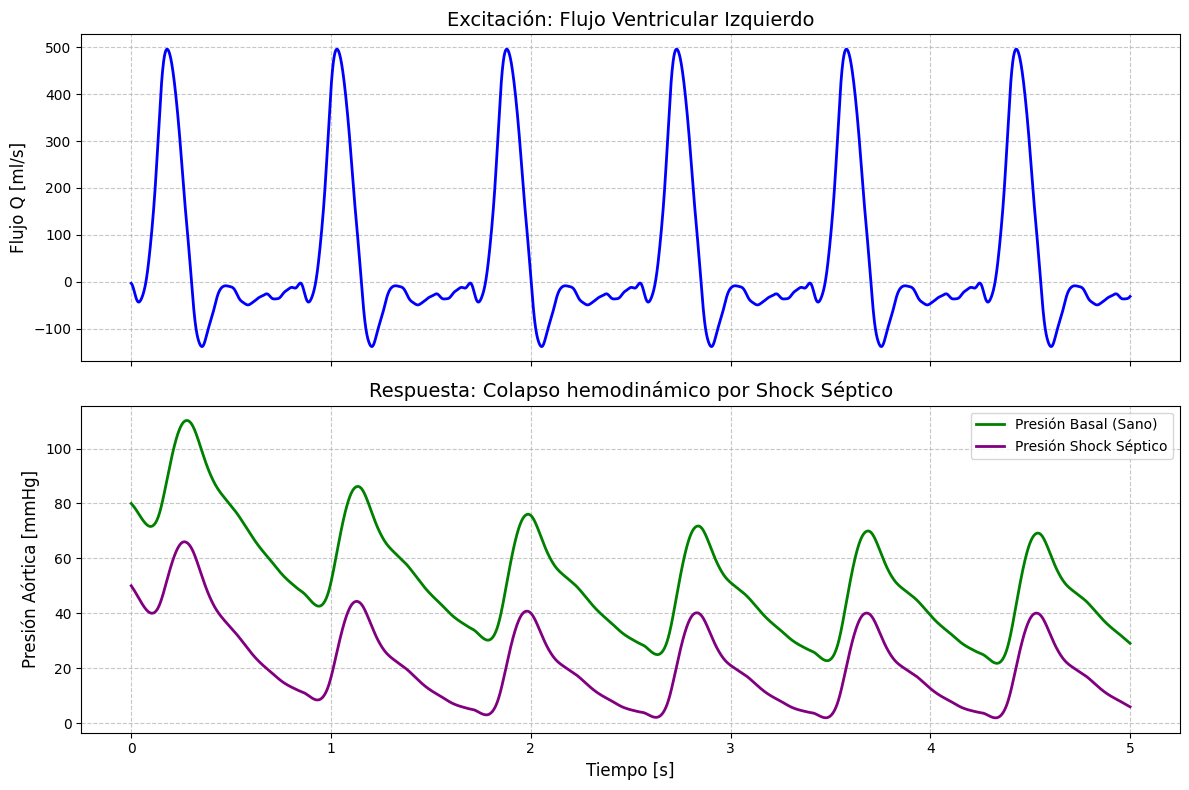

In [3]:
# -------------------------------------------------------------------------
# SIMULACIÓN 1c: SHOCK SÉPTICO
# -------------------------------------------------------------------------

# 1. Definición del vector de tiempo y flujo
Ts = 0.001
t = np.arange(0, 5, Ts)
T0 = 0.85
Qmax = 500

Q_entrada = Q_Sim(Qmax, T0, t)

# 2. Parámetros Fisiológicos Basales
Ca_basal = 1.1  # ml/mmHg
Rp_basal = 0.9  # mmHg·s/ml

# 3. Parámetros para Shock Séptico (Caída brutal de Rp, aumento de Ca)
Ca_sepsis = Ca_basal * 1.20
Rp_sepsis = Rp_basal * 0.40

# 4. Cálculo de las presiones
# Recalculamos la basal con condición inicial normal (80) para que la gráfica sea fiel
def resolver_wk2_euler_basal(Q, t, Ca, Rp):
    dt = t[1] - t[0]
    P = np.zeros(len(t))
    P[0] = 80.0
    for i in range(1, len(t)):
        P[i] = P[i-1] + (((Q[i-1] / Ca) - (P[i-1] / (Rp * Ca))) * dt)
    return P

P_basal = resolver_wk2_euler_basal(Q_entrada, t, Ca_basal, Rp_basal)
P_sepsis = resolver_wk2_euler(Q_entrada, t, Ca_sepsis, Rp_sepsis) # Usa P[0]=50

# 5. Visualización
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(t, Q_entrada, 'b', linewidth=2)
ax1.set_ylabel('Flujo Q [ml/s]', fontsize=12)
ax1.set_title('Excitación: Flujo Ventricular Izquierdo', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(t, P_basal, 'g', linewidth=2, label='Presión Basal (Sano)')
ax2.plot(t, P_sepsis, 'purple', linewidth=2, label='Presión Shock Séptico')
ax2.set_xlabel('Tiempo [s]', fontsize=12)
ax2.set_ylabel('Presión Aórtica [mmHg]', fontsize=12)
ax2.set_title('Respuesta: Colapso hemodinámico por Shock Séptico', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Conclusión del análisis (1 c)
La simulación del shock séptico refleja el colapso hemodinámico del paciente:

1. **Hipotensión Severa (Caída de la componente DC):** La curva púrpura se encuentra hundida respecto a la basal. Al reducirse la resistencia periférica ($R_P$) a menos de la mitad, el sistema no puede mantener la presión media. La sangre fluye hacia la periferia casi sin oposición.
2. **Descarga Diastólica Pronunciada:** En la fase de diástole (cuando el flujo de entrada es cero), se observa que la curva de presión cae abruptamente. La constante de tiempo $\tau = R_P \cdot C_A$ del circuito ha disminuido muchísimo. El "capacitor vascular" se vacía rápidamente a través de una resistencia mínima, impidiendo mantener una presión diastólica suficiente para perfundir órganos vitales como el corazón (arterias coronarias) o el cerebro.